# Timestep Analysis: Vital Signs Time Delta Distribution

This notebook analyzes the temporal distribution of vital sign recordings to determine the optimal timestep for LSTM data preparation.

**Key Questions:**
1. How are vitals stored? (one row per vital vs pivoted)
2. How many vitals are recorded at each timestamp? (complete vs sparse)
3. What is the time delta between consecutive complete timestamps?
4. What timestep should we use for LSTM sequences?

## 1. Setup

In [28]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Configuration
SILVER_PATH = Path("../output/silver/silver_vitals.parquet")

# Connect to DuckDB
conn = duckdb.connect(":memory:")
conn.execute(f"CREATE VIEW vitals AS SELECT * FROM read_parquet('{SILVER_PATH}')")

# Vital sign reference
VITALS = {
    "8310-5": "body_temperature",
    "8867-4": "heart_rate",
    "9279-1": "respiratory_rate",
    "2708-6": "oxygen_saturation",
    "8480-6": "systolic_bp",
    "8462-4": "diastolic_bp",
}

print(f"Loaded data from {SILVER_PATH}")
print(f"Total vitals tracked: {len(VITALS)}")

Loaded data from ../output/silver/silver_vitals.parquet
Total vitals tracked: 6


## 2. Data Structure Overview

Understanding how the data is organized: each row is a single vital observation.

In [29]:
# Basic data overview
print("=" * 60)
print("DATA STRUCTURE OVERVIEW")
print("=" * 60)

# Schema
print("\n--- Schema ---")
schema = conn.execute("DESCRIBE vitals").df()
display(schema)

# Sample rows
print("\n--- Sample Data (same encounter, same timestamp) ---")
sample = conn.execute("""
    SELECT * FROM vitals 
    WHERE encounter_id = (SELECT encounter_id FROM vitals LIMIT 1)
    ORDER BY effective_datetime, loinc_code
    LIMIT 12
""").df()
sample['vital_name'] = sample['loinc_code'].map(VITALS)
display(sample)

# Counts
print("\n--- Data Counts ---")
counts = conn.execute("""
    SELECT 
        COUNT(*) as total_rows,
        COUNT(DISTINCT patient_id) as unique_patients,
        COUNT(DISTINCT encounter_id) as unique_encounters,
        COUNT(DISTINCT loinc_code) as unique_vitals
    FROM vitals
""").df()
display(counts)

print("\n>>> KEY INSIGHT: Each row is ONE vital observation.")
print(">>> Multiple vitals at the same timestamp are stored as separate rows.")

DATA STRUCTURE OVERVIEW

--- Schema ---


,column_name,column_type,null,key,default,extra
0,patient_id,VARCHAR,YES,None,None,None
1,encounter_id,VARCHAR,YES,None,None,None
2,effective_datetime,VARCHAR,YES,None,None,None
3,loinc_code,VARCHAR,YES,None,None,None
4,value,DOUBLE,YES,None,None,None
5,unit,VARCHAR,YES,None,None,None



--- Sample Data (same encounter, same timestamp) ---


,patient_id,encounter_id,effective_datetime,loinc_code,value,unit,vital_name
0,000000ba-735e-5858-a92d-b856d73dd69a,ab67e413-be5f-5c55-97d2-615c1941d950,2169-09-06T17:34:00-04:00,2708-6,98.0,%,oxygen_saturation
1,000000ba-735e-5858-a92d-b856d73dd69a,ab67e413-be5f-5c55-97d2-615c1941d950,2169-09-06T17:34:00-04:00,8310-5,98.7,F,body_temperature
2,000000ba-735e-5858-a92d-b856d73dd69a,ab67e413-be5f-5c55-97d2-615c1941d950,2169-09-06T17:34:00-04:00,8462-4,71.0,mm[Hg],diastolic_bp
3,000000ba-735e-5858-a92d-b856d73dd69a,ab67e413-be5f-5c55-97d2-615c1941d950,2169-09-06T17:34:00-04:00,8480-6,141.0,mm[Hg],systolic_bp
4,000000ba-735e-5858-a92d-b856d73dd69a,ab67e413-be5f-5c55-97d2-615c1941d950,2169-09-06T17:34:00-04:00,8867-4,96.0,beats/minute,heart_rate
5,000000ba-735e-5858-a92d-b856d73dd69a,ab67e413-be5f-5c55-97d2-615c1941d950,2169-09-06T17:34:00-04:00,9279-1,18.0,breaths/minute,respiratory_rate
6,000000ba-735e-5858-a92d-b856d73dd69a,ab67e413-be5f-5c55-97d2-615c1941d950,2169-09-06T17:35:00-04:00,2708-6,98.0,%,oxygen_saturation
7,000000ba-735e-5858-a92d-b856d73dd69a,ab67e413-be5f-5c55-97d2-615c1941d950,2169-09-06T17:35:00-04:00,8310-5,98.7,F,body_temperature
8,000000ba-735e-5858-a92d-b856d73dd69a,ab67e413-be5f-5c55-97d2-615c1941d950,2169-09-06T17:35:00-04:00,8462-4,71.0,mm[Hg],diastolic_bp
9,000000ba-735e-5858-a92d-b856d73dd69a,ab67e413-be5f-5c55-97d2-615c1941d950,2169-09-06T17:35:00-04:00,8480-6,141.0,mm[Hg],systolic_bp



--- Data Counts ---


,total_rows,unique_patients,unique_encounters,unique_vitals
0,10996821,205504,425087,6



>>> KEY INSIGHT: Each row is ONE vital observation.
>>> Multiple vitals at the same timestamp are stored as separate rows.


## 3. Timestamp Completeness Analysis

How many vitals are recorded at each timestamp? A "complete" timestamp has all 6 vitals.

TIMESTAMP COMPLETENESS ANALYSIS

--- How many vitals are recorded at each timestamp? ---


,num_vitals,num_timestamps,pct,cumulative_pct,label
0,2,56365,2.95,2.95,Sparse
1,3,34808,1.82,4.77,Sparse
2,4,36987,1.94,6.71,Sparse
3,5,522789,27.35,34.06,Near-complete
4,6,1260313,65.94,100.00,Complete


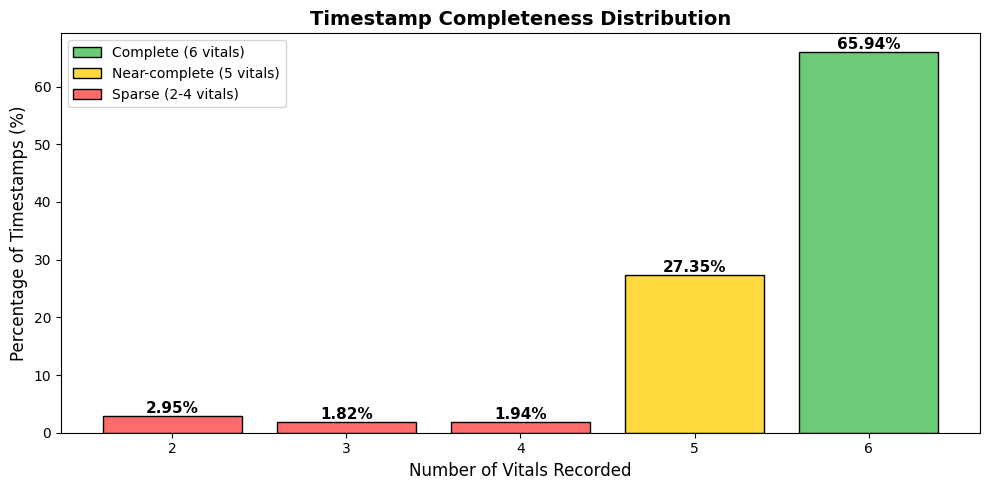


>>> SUMMARY:
    - Complete timestamps (6 vitals): 65.94%
    - Near-complete timestamps (5+ vitals): 93.28999999999999%
    - Sparse timestamps (2-4 vitals): 6.71%


In [30]:
print("=" * 60)
print("TIMESTAMP COMPLETENESS ANALYSIS")
print("=" * 60)

# Distribution of vitals per timestamp
print("\n--- How many vitals are recorded at each timestamp? ---")
completeness = conn.execute("""
    WITH timestamp_vitals AS (
        SELECT 
            encounter_id,
            effective_datetime,
            COUNT(DISTINCT loinc_code) as num_vitals
        FROM vitals
        GROUP BY encounter_id, effective_datetime
    )
    SELECT 
        num_vitals,
        COUNT(*) as num_timestamps,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) as pct
    FROM timestamp_vitals
    GROUP BY num_vitals
    ORDER BY num_vitals
""").df()
completeness['cumulative_pct'] = completeness['pct'].cumsum().round(2)
completeness['label'] = completeness['num_vitals'].apply(
    lambda x: 'Complete' if x == 6 else ('Near-complete' if x == 5 else 'Sparse')
)
display(completeness)

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#ff6b6b' if x < 5 else ('#ffd93d' if x == 5 else '#6bcb77') for x in completeness['num_vitals']]
bars = ax.bar(completeness['num_vitals'].astype(str), completeness['pct'], color=colors, edgecolor='black')
ax.set_xlabel('Number of Vitals Recorded', fontsize=12)
ax.set_ylabel('Percentage of Timestamps (%)', fontsize=12)
ax.set_title('Timestamp Completeness Distribution', fontsize=14, fontweight='bold')

# Add percentage labels
for bar, pct in zip(bars, completeness['pct']):
    ax.annotate(f'{pct}%', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#6bcb77', edgecolor='black', label='Complete (6 vitals)'),
    Patch(facecolor='#ffd93d', edgecolor='black', label='Near-complete (5 vitals)'),
    Patch(facecolor='#ff6b6b', edgecolor='black', label='Sparse (2-4 vitals)')
]
ax.legend(handles=legend_elements, loc='upper left')
plt.tight_layout()
plt.show()

# Summary
complete_pct = completeness[completeness['num_vitals'] == 6]['pct'].values[0]
near_complete_pct = completeness[completeness['num_vitals'] >= 5]['pct'].sum()
print(f"\n>>> SUMMARY:")
print(f"    - Complete timestamps (6 vitals): {complete_pct}%")
print(f"    - Near-complete timestamps (5+ vitals): {near_complete_pct}%")
print(f"    - Sparse timestamps (2-4 vitals): {100 - near_complete_pct:.2f}%")

## 4. Missing Vital Analysis

When a timestamp has only 5 vitals, which one is missing?

MISSING VITAL ANALYSIS

--- Which vital is most commonly missing when 5/6 are recorded? ---


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,vital_name,missing_loinc,times_missing,pct
0,body_temperature,8310-5,471200,90.13
1,oxygen_saturation,2708-6,42982,8.22
2,respiratory_rate,9279-1,6895,1.32
3,heart_rate,8867-4,1712,0.33


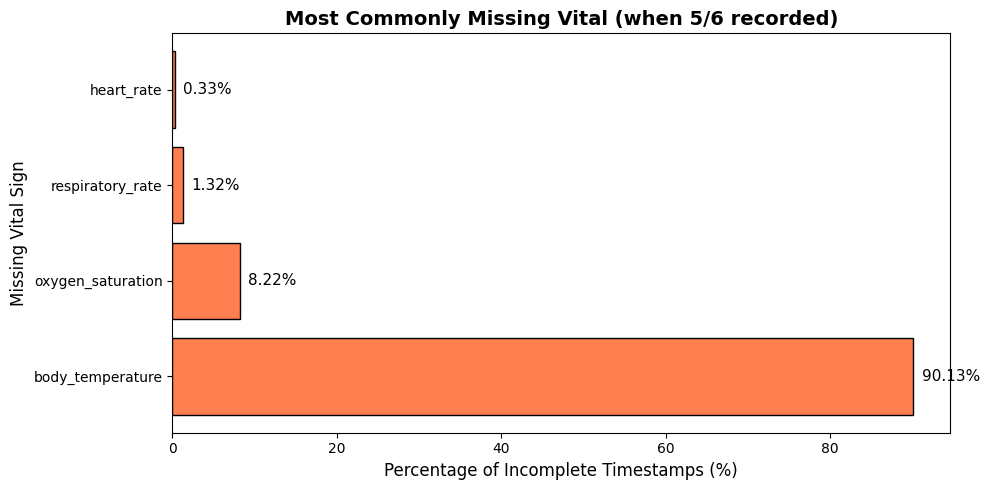


>>> KEY FINDING: body_temperature is missing 90.13% of the time.
    Consider imputing this vital or using 5+ vitals as 'complete'.


In [31]:
print("=" * 60)
print("MISSING VITAL ANALYSIS")
print("=" * 60)

print("\n--- Which vital is most commonly missing when 5/6 are recorded? ---")
missing = conn.execute("""
    WITH all_loinc AS (
        SELECT DISTINCT loinc_code FROM vitals
    ),
    timestamp_vitals AS (
        SELECT 
            encounter_id,
            effective_datetime,
            LIST(DISTINCT loinc_code) as present_loincs
        FROM vitals
        GROUP BY encounter_id, effective_datetime
        HAVING COUNT(DISTINCT loinc_code) = 5
    )
    SELECT 
        loinc_code as missing_loinc,
        COUNT(*) as times_missing,
        ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM timestamp_vitals), 2) as pct
    FROM all_loinc, timestamp_vitals
    WHERE NOT list_contains(present_loincs, loinc_code)
    GROUP BY loinc_code
    ORDER BY times_missing DESC
""").df()
missing['vital_name'] = missing['missing_loinc'].map(VITALS)
display(missing[['vital_name', 'missing_loinc', 'times_missing', 'pct']])

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(missing['vital_name'], missing['pct'], color='coral', edgecolor='black')
ax.set_xlabel('Percentage of Incomplete Timestamps (%)', fontsize=12)
ax.set_ylabel('Missing Vital Sign', fontsize=12)
ax.set_title('Most Commonly Missing Vital (when 5/6 recorded)', fontsize=14, fontweight='bold')

for bar, pct in zip(bars, missing['pct']):
    ax.annotate(f'{pct}%', xy=(bar.get_width() + 1, bar.get_y() + bar.get_height()/2),
                ha='left', va='center', fontsize=11)

plt.tight_layout()
plt.show()

top_missing = missing.iloc[0]
print(f"\n>>> KEY FINDING: {top_missing['vital_name']} is missing {top_missing['pct']}% of the time.")
print(f"    Consider imputing this vital or using 5+ vitals as 'complete'.")

## 5. Time Delta Distribution (Complete Timestamps)

Now we analyze the time between consecutive **complete** timestamps within each encounter.

In [32]:
print("=" * 60)
print("TIME DELTA ANALYSIS - COMPLETE TIMESTAMPS (6 VITALS)")
print("=" * 60)

# Percentile distribution
print("\n--- Time Delta Percentiles (minutes) ---")
delta_stats = conn.execute("""
    WITH timestamp_vitals AS (
        SELECT 
            encounter_id,
            effective_datetime::TIMESTAMP as ts,
            COUNT(DISTINCT loinc_code) as num_vitals
        FROM vitals
        GROUP BY encounter_id, effective_datetime
    ),
    complete_ts AS (
        SELECT encounter_id, ts
        FROM timestamp_vitals
        WHERE num_vitals = 6
    ),
    deltas AS (
        SELECT 
            encounter_id,
            ts,
            LAG(ts) OVER (PARTITION BY encounter_id ORDER BY ts) as prev_ts,
            EXTRACT(EPOCH FROM (ts - LAG(ts) OVER (PARTITION BY encounter_id ORDER BY ts))) / 60.0 as delta_min
        FROM complete_ts
    )
    SELECT 
        COUNT(*) as n_deltas,
        ROUND(MIN(delta_min), 1) as min,
        ROUND(PERCENTILE_CONT(0.10) WITHIN GROUP (ORDER BY delta_min), 1) as p10,
        ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY delta_min), 1) as p25,
        ROUND(PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY delta_min), 1) as p50_median,
        ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY delta_min), 1) as p75,
        ROUND(PERCENTILE_CONT(0.90) WITHIN GROUP (ORDER BY delta_min), 1) as p90,
        ROUND(PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY delta_min), 1) as p95,
        ROUND(MAX(delta_min), 1) as max
    FROM deltas
    WHERE delta_min IS NOT NULL
""").df()
display(delta_stats.T.rename(columns={0: 'minutes'}))

median_min = delta_stats['p50_median'].values[0]
median_hrs = median_min / 60
print(f"\n>>> MEDIAN TIME DELTA: {median_min:.0f} minutes ({median_hrs:.1f} hours)")

TIME DELTA ANALYSIS - COMPLETE TIMESTAMPS (6 VITALS)

--- Time Delta Percentiles (minutes) ---


,minutes
n_deltas,843575.0
min,1.0
p10,2.0
p25,70.0
p50_median,162.0
p75,261.0
p90,382.0
p95,480.0
max,23387.0



>>> MEDIAN TIME DELTA: 162 minutes (2.7 hours)



--- Time Delta Histogram ---


,time_bucket,count,pct,cumulative_pct
0,0-1 hr,194941,23.11,23.11
1,1-2 hrs,124386,14.75,37.86
2,2-3 hrs,146498,17.37,55.23
3,3-4 hrs,129876,15.40,70.63
4,4-6 hrs,149061,17.67,88.30
5,6-8 hrs,56833,6.74,95.04
6,>8 hrs,41980,4.98,100.02


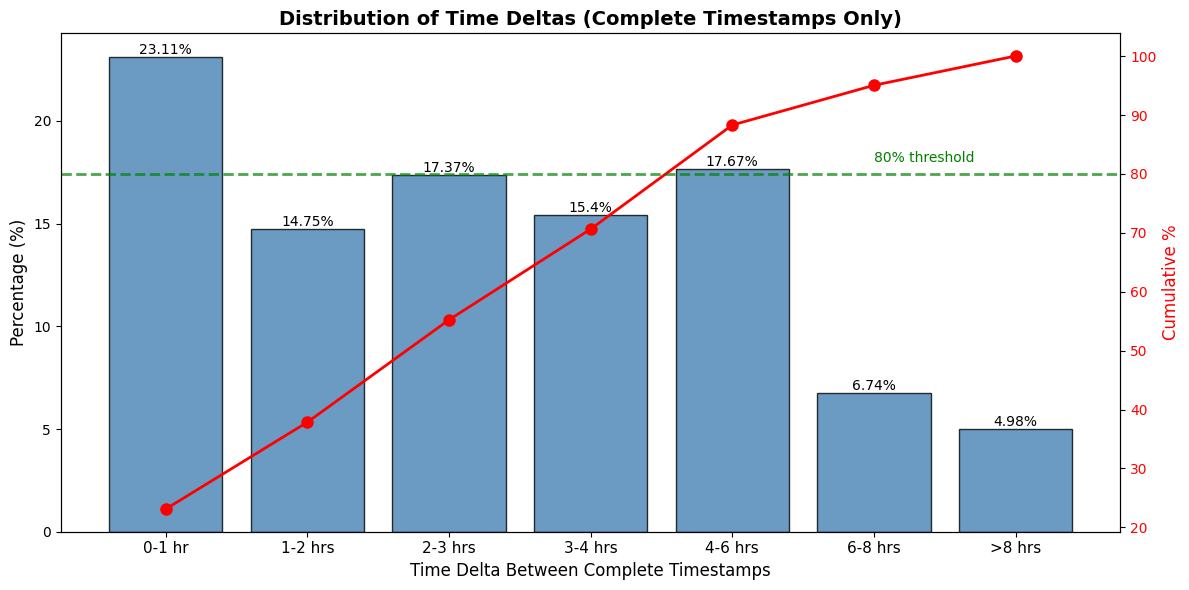

In [33]:
# Histogram of time deltas
print("\n--- Time Delta Histogram ---")
buckets = conn.execute("""
    WITH timestamp_vitals AS (
        SELECT 
            encounter_id,
            effective_datetime::TIMESTAMP as ts,
            COUNT(DISTINCT loinc_code) as num_vitals
        FROM vitals
        GROUP BY encounter_id, effective_datetime
    ),
    complete_ts AS (
        SELECT encounter_id, ts
        FROM timestamp_vitals
        WHERE num_vitals = 6
    ),
    deltas AS (
        SELECT 
            EXTRACT(EPOCH FROM (ts - LAG(ts) OVER (PARTITION BY encounter_id ORDER BY ts))) / 60.0 as delta_min
        FROM complete_ts
    )
    SELECT 
        CASE 
            WHEN delta_min <= 60 THEN '0-1 hr'
            WHEN delta_min <= 120 THEN '1-2 hrs'
            WHEN delta_min <= 180 THEN '2-3 hrs'
            WHEN delta_min <= 240 THEN '3-4 hrs'
            WHEN delta_min <= 360 THEN '4-6 hrs'
            WHEN delta_min <= 480 THEN '6-8 hrs'
            ELSE '>8 hrs'
        END as time_bucket,
        CASE 
            WHEN delta_min <= 60 THEN 1
            WHEN delta_min <= 120 THEN 2
            WHEN delta_min <= 180 THEN 3
            WHEN delta_min <= 240 THEN 4
            WHEN delta_min <= 360 THEN 5
            WHEN delta_min <= 480 THEN 6
            ELSE 7
        END as bucket_order,
        COUNT(*) as count,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) as pct
    FROM deltas
    WHERE delta_min IS NOT NULL
    GROUP BY 1, 2
    ORDER BY bucket_order
""").df()
buckets['cumulative_pct'] = buckets['pct'].cumsum().round(2)
display(buckets[['time_bucket', 'count', 'pct', 'cumulative_pct']])

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(buckets))
bars = ax.bar(x, buckets['pct'], color='steelblue', edgecolor='black', alpha=0.8, label='Percentage')
ax.set_xticks(x)
ax.set_xticklabels(buckets['time_bucket'], fontsize=11)
ax.set_xlabel('Time Delta Between Complete Timestamps', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Distribution of Time Deltas (Complete Timestamps Only)', fontsize=14, fontweight='bold')

# Add percentage labels
for bar, pct in zip(bars, buckets['pct']):
    ax.annotate(f'{pct}%', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=10)

# Cumulative line
ax2 = ax.twinx()
ax2.plot(x, buckets['cumulative_pct'], color='red', marker='o', linewidth=2, markersize=8, label='Cumulative %')
ax2.set_ylabel('Cumulative %', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.axhline(y=80, color='green', linestyle='--', alpha=0.7, linewidth=2)
ax2.annotate('80% threshold', xy=(5, 82), color='green', fontsize=10)

plt.tight_layout()
plt.show()

### 5a. Average Delta by Position (1st, 2nd, 3rd, ...)

Do encounters start with dense measurements that spread out over time, or vice versa?

AVERAGE DELTA BY POSITION (1st, 2nd, 3rd, ...)

--- Average/Median Delta by Measurement Position ---


,delta_idx,avg_delta_min,median_delta_min,n_encounters
0,2,141.9,115.0,367432
1,3,222.4,190.0,232168
2,4,211.3,172.0,116762
3,5,223.0,181.0,56647
4,6,228.9,192.0,29601
5,7,230.6,197.0,16265
6,8,238.0,201.5,9142
7,9,244.0,211.0,5340
8,10,260.9,221.0,3266
9,11,266.4,233.0,2112


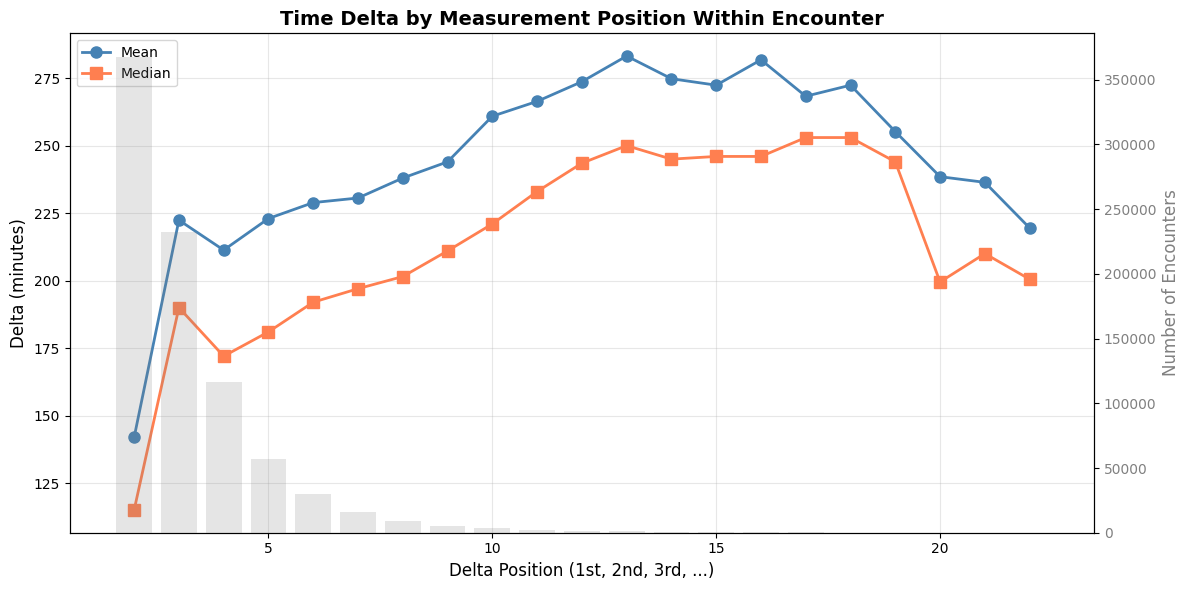


>>> TREND: Measurements tend to spread out (deltas increase) over the encounter.
    Early positions avg: 206 min | Later positions avg: 244 min


In [34]:
print("=" * 60)
print("AVERAGE DELTA BY POSITION (1st, 2nd, 3rd, ...)")
print("=" * 60)

# Compute average delta by position within encounters
delta_by_position = conn.execute("""
    WITH timestamp_vitals AS (
        SELECT 
            encounter_id,
            effective_datetime::TIMESTAMP as ts,
            COUNT(DISTINCT loinc_code) as num_vitals
        FROM vitals
        GROUP BY encounter_id, effective_datetime
    ),
    complete_ts AS (
        SELECT encounter_id, ts
        FROM timestamp_vitals
        WHERE num_vitals = 6
    ),
    deltas AS (
        SELECT 
            encounter_id,
            ts,
            EXTRACT(EPOCH FROM (ts - LAG(ts) OVER (PARTITION BY encounter_id ORDER BY ts))) / 60.0 AS delta_min,
            ROW_NUMBER() OVER (PARTITION BY encounter_id ORDER BY ts) AS delta_idx
        FROM complete_ts
    )
    SELECT 
        delta_idx,
        ROUND(AVG(delta_min), 1) AS avg_delta_min,
        ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY delta_min), 1) AS median_delta_min,
        COUNT(*) AS n_encounters
    FROM deltas
    WHERE delta_min IS NOT NULL
    GROUP BY delta_idx
    ORDER BY delta_idx
""").df()

# Show first 15 positions (most encounters won't have more)
print("\n--- Average/Median Delta by Measurement Position ---")
display(delta_by_position.head(15))

# Visualization
fig, ax1 = plt.subplots(figsize=(12, 6))

# Filter to positions with reasonable sample size (e.g., at least 50 encounters)
plot_data = delta_by_position[delta_by_position['n_encounters'] >= 50].copy()

x = plot_data['delta_idx']
ax1.plot(x, plot_data['avg_delta_min'], marker='o', color='steelblue', linewidth=2, markersize=8, label='Mean')
ax1.plot(x, plot_data['median_delta_min'], marker='s', color='coral', linewidth=2, markersize=8, label='Median')
ax1.set_xlabel('Delta Position (1st, 2nd, 3rd, ...)', fontsize=12)
ax1.set_ylabel('Delta (minutes)', fontsize=12)
ax1.set_title('Time Delta by Measurement Position Within Encounter', fontsize=14, fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Secondary axis for encounter count
ax2 = ax1.twinx()
ax2.bar(x, plot_data['n_encounters'], alpha=0.2, color='gray', label='# Encounters')
ax2.set_ylabel('Number of Encounters', fontsize=12, color='gray')
ax2.tick_params(axis='y', labelcolor='gray')

plt.tight_layout()
plt.show()

# Trend analysis
first_5_avg = plot_data.head(5)['avg_delta_min'].mean()
last_5_avg = plot_data.tail(5)['avg_delta_min'].mean() if len(plot_data) >= 10 else plot_data['avg_delta_min'].mean()
trend = "spread out (deltas increase)" if last_5_avg > first_5_avg * 1.1 else \
        "compress (deltas decrease)" if last_5_avg < first_5_avg * 0.9 else "remain stable"

print(f"\n>>> TREND: Measurements tend to {trend} over the encounter.")
print(f"    Early positions avg: {first_5_avg:.0f} min | Later positions avg: {last_5_avg:.0f} min")

### 5b. Per-Encounter Average Delta Distribution

Instead of pooling all deltas together, what does the distribution look like when we compute the average delta *per encounter* first?

PER-ENCOUNTER AVERAGE DELTA DISTRIBUTION

--- Per-Encounter Average Delta Percentiles (minutes) ---


,minutes
n_encounters,367432.0
min,1.0
p10,67.5
p25,109.5
p50_median,164.5
p75,239.2
p90,330.0
p95,401.0
max,11786.0


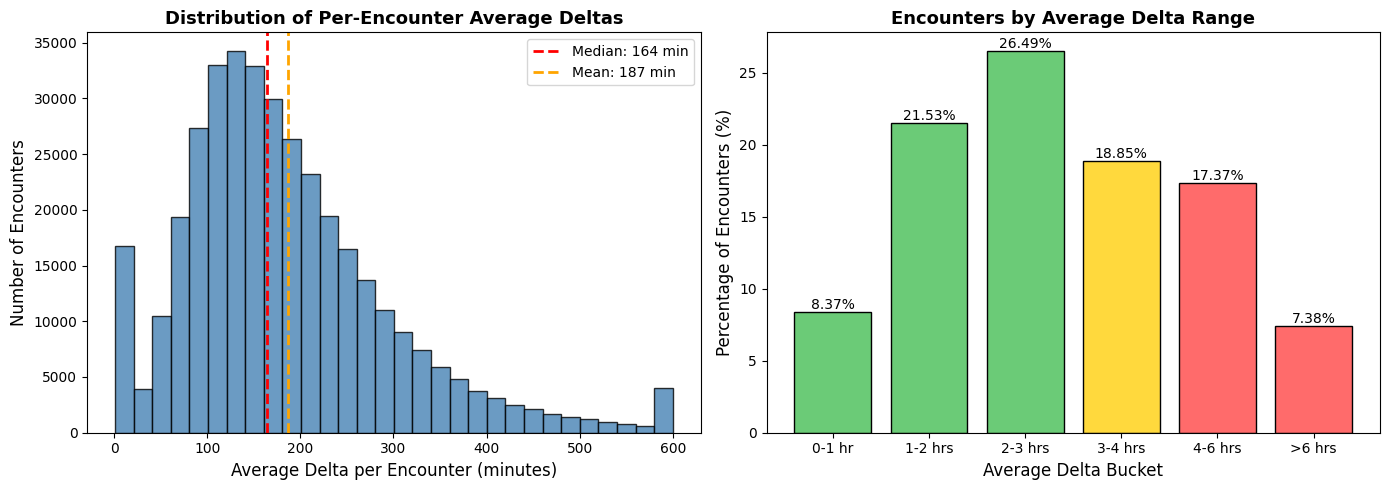


>>> COMPARISON: Pooled vs Encounter-Level
    Pooled delta median:      162 min
    Encounter-avg median:     164 min

>>> INTERPRETATION:
    Encounter-level is HIGHER than pooled, suggesting encounters
    with many observations (and thus more deltas) have shorter intervals.


In [35]:
print("=" * 60)
print("PER-ENCOUNTER AVERAGE DELTA DISTRIBUTION")
print("=" * 60)

# Compute per-encounter average delta, then analyze distribution
encounter_avg_stats = conn.execute("""
    WITH timestamp_vitals AS (
        SELECT 
            encounter_id,
            effective_datetime::TIMESTAMP as ts,
            COUNT(DISTINCT loinc_code) as num_vitals
        FROM vitals
        GROUP BY encounter_id, effective_datetime
    ),
    complete_ts AS (
        SELECT encounter_id, ts
        FROM timestamp_vitals
        WHERE num_vitals = 6
    ),
    deltas AS (
        SELECT 
            encounter_id,
            EXTRACT(EPOCH FROM (ts - LAG(ts) OVER (PARTITION BY encounter_id ORDER BY ts))) / 60.0 AS delta_min
        FROM complete_ts
    ),
    encounter_avg AS (
        SELECT 
            encounter_id,
            AVG(delta_min) AS avg_delta_min,
            COUNT(*) AS n_deltas
        FROM deltas
        WHERE delta_min IS NOT NULL
        GROUP BY encounter_id
    )
    SELECT 
        COUNT(*) AS n_encounters,
        ROUND(MIN(avg_delta_min), 1) AS min,
        ROUND(PERCENTILE_CONT(0.10) WITHIN GROUP (ORDER BY avg_delta_min), 1) AS p10,
        ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY avg_delta_min), 1) AS p25,
        ROUND(PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY avg_delta_min), 1) AS p50_median,
        ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY avg_delta_min), 1) AS p75,
        ROUND(PERCENTILE_CONT(0.90) WITHIN GROUP (ORDER BY avg_delta_min), 1) AS p90,
        ROUND(PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY avg_delta_min), 1) AS p95,
        ROUND(MAX(avg_delta_min), 1) AS max
    FROM encounter_avg
""").df()

print("\n--- Per-Encounter Average Delta Percentiles (minutes) ---")
display(encounter_avg_stats.T.rename(columns={0: 'minutes'}))

# Get raw data for histogram
encounter_avgs = conn.execute("""
    WITH timestamp_vitals AS (
        SELECT 
            encounter_id,
            effective_datetime::TIMESTAMP as ts,
            COUNT(DISTINCT loinc_code) as num_vitals
        FROM vitals
        GROUP BY encounter_id, effective_datetime
    ),
    complete_ts AS (
        SELECT encounter_id, ts
        FROM timestamp_vitals
        WHERE num_vitals = 6
    ),
    deltas AS (
        SELECT 
            encounter_id,
            EXTRACT(EPOCH FROM (ts - LAG(ts) OVER (PARTITION BY encounter_id ORDER BY ts))) / 60.0 AS delta_min
        FROM complete_ts
    )
    SELECT 
        encounter_id,
        AVG(delta_min) AS avg_delta_min
    FROM deltas
    WHERE delta_min IS NOT NULL
    GROUP BY encounter_id
""").df()

# Histogram visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Raw histogram
ax1 = axes[0]
ax1.hist(encounter_avgs['avg_delta_min'].clip(upper=600), bins=30, color='steelblue', edgecolor='black', alpha=0.8)
ax1.axvline(encounter_avg_stats['p50_median'].values[0], color='red', linestyle='--', linewidth=2, label=f"Median: {encounter_avg_stats['p50_median'].values[0]:.0f} min")
ax1.axvline(encounter_avgs['avg_delta_min'].mean(), color='orange', linestyle='--', linewidth=2, label=f"Mean: {encounter_avgs['avg_delta_min'].mean():.0f} min")
ax1.set_xlabel('Average Delta per Encounter (minutes)', fontsize=12)
ax1.set_ylabel('Number of Encounters', fontsize=12)
ax1.set_title('Distribution of Per-Encounter Average Deltas', fontsize=13, fontweight='bold')
ax1.legend()

# Right: Bucketed distribution
ax2 = axes[1]
enc_buckets = conn.execute("""
    WITH timestamp_vitals AS (
        SELECT 
            encounter_id,
            effective_datetime::TIMESTAMP as ts,
            COUNT(DISTINCT loinc_code) as num_vitals
        FROM vitals
        GROUP BY encounter_id, effective_datetime
    ),
    complete_ts AS (
        SELECT encounter_id, ts
        FROM timestamp_vitals
        WHERE num_vitals = 6
    ),
    deltas AS (
        SELECT 
            encounter_id,
            EXTRACT(EPOCH FROM (ts - LAG(ts) OVER (PARTITION BY encounter_id ORDER BY ts))) / 60.0 AS delta_min
        FROM complete_ts
    ),
    encounter_avg AS (
        SELECT 
            encounter_id,
            AVG(delta_min) AS avg_delta_min
        FROM deltas
        WHERE delta_min IS NOT NULL
        GROUP BY encounter_id
    )
    SELECT 
        CASE 
            WHEN avg_delta_min <= 60 THEN '0-1 hr'
            WHEN avg_delta_min <= 120 THEN '1-2 hrs'
            WHEN avg_delta_min <= 180 THEN '2-3 hrs'
            WHEN avg_delta_min <= 240 THEN '3-4 hrs'
            WHEN avg_delta_min <= 360 THEN '4-6 hrs'
            ELSE '>6 hrs'
        END as avg_delta_bucket,
        CASE 
            WHEN avg_delta_min <= 60 THEN 1
            WHEN avg_delta_min <= 120 THEN 2
            WHEN avg_delta_min <= 180 THEN 3
            WHEN avg_delta_min <= 240 THEN 4
            WHEN avg_delta_min <= 360 THEN 5
            ELSE 6
        END as bucket_order,
        COUNT(*) as n_encounters,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) as pct
    FROM encounter_avg
    GROUP BY 1, 2
    ORDER BY bucket_order
""").df()

colors = ['#6bcb77' if x <= 3 else '#ffd93d' if x <= 4 else '#ff6b6b' for x in enc_buckets['bucket_order']]
bars = ax2.bar(enc_buckets['avg_delta_bucket'], enc_buckets['pct'], color=colors, edgecolor='black')
ax2.set_xlabel('Average Delta Bucket', fontsize=12)
ax2.set_ylabel('Percentage of Encounters (%)', fontsize=12)
ax2.set_title('Encounters by Average Delta Range', fontsize=13, fontweight='bold')

for bar, pct in zip(bars, enc_buckets['pct']):
    ax2.annotate(f'{pct}%', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Compare pooled vs encounter-level
pooled_median = delta_stats['p50_median'].values[0]  # From earlier cell
encounter_median = encounter_avg_stats['p50_median'].values[0]

print(f"\n>>> COMPARISON: Pooled vs Encounter-Level")
print(f"    Pooled delta median:      {pooled_median:.0f} min")
print(f"    Encounter-avg median:     {encounter_median:.0f} min")
print(f"\n>>> INTERPRETATION:")
if encounter_median < pooled_median:
    print("    Encounter-level is LOWER than pooled, suggesting some encounters")
    print("    with many short deltas skew the pooled distribution.")
else:
    print("    Encounter-level is HIGHER than pooled, suggesting encounters")
    print("    with many observations (and thus more deltas) have shorter intervals.")

### 5c. Encounter Duration vs Observation Frequency

How does observation frequency change with encounter length? Do longer encounters maintain the same measurement density?

ENCOUNTER DURATION vs OBSERVATION FREQUENCY

--- Encounter Metrics Summary (n=367,432 encounters with 2+ observations) ---


,n_observations,duration_hrs,obs_rate_per_hr
count,367432.00,367432.00,367432.00
mean,3.30,7.16,4.33
std,1.63,7.71,18.77
min,2.00,0.02,0.01
25%,2.00,3.08,0.40
50%,3.00,5.05,0.57
75%,4.00,8.20,0.85
max,44.00,392.87,120.00



--- Observation Rate by Duration Bucket ---


,duration_bucket,n_encounters,avg_n_obs,median_n_obs,avg_duration_hrs,avg_obs_rate_per_hr,median_obs_rate_per_hr
4,<1 hr,20360,2.05,2.0,0.18,67.20,60.00
1,1-4 hrs,115481,2.47,2.0,2.73,0.99,0.89
3,4-12 hrs,180589,3.27,3.0,6.66,0.52,0.48
2,12-24 hrs,37588,5.08,5.0,17.11,0.30,0.30
0,1-3 days,12922,7.31,7.0,32.38,0.23,0.23
5,>3 days,492,15.52,15.0,93.95,0.17,0.17


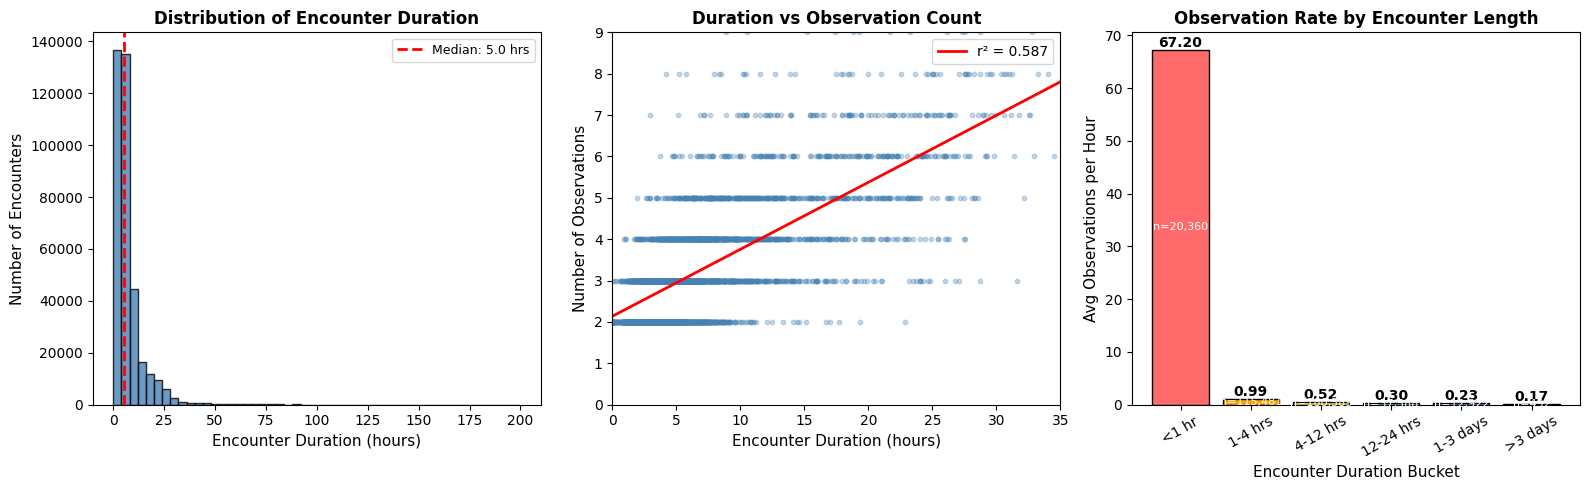


KEY FINDINGS

1. CORRELATION: Duration vs # Observations = 0.766 (r² = 0.587)
   Longer encounters have more observations (expected).

2. OBSERVATION FREQUENCY:
   - Short encounters (<1 hr): 67.20 obs/hr
   - Long encounters (>3 days): 0.17 obs/hr
   - Ratio: 396.3x higher for short encounters

>>> INTERPRETATION: Observation density DECREASES significantly with encounter length.
    Longer stays have sparser vital measurements relative to time.


In [37]:
print("=" * 60)
print("ENCOUNTER DURATION vs OBSERVATION FREQUENCY")
print("=" * 60)

# Compute per-encounter metrics: n_observations, duration_hrs, obs_rate_per_hr
encounter_metrics = conn.execute("""
    WITH timestamp_vitals AS (
        SELECT 
            encounter_id,
            effective_datetime::TIMESTAMP as ts,
            COUNT(DISTINCT loinc_code) as num_vitals
        FROM vitals
        GROUP BY encounter_id, effective_datetime
    ),
    complete_ts AS (
        SELECT encounter_id, ts
        FROM timestamp_vitals
        WHERE num_vitals = 6
    ),
    encounter_stats AS (
        SELECT 
            encounter_id,
            COUNT(*) AS n_observations,
            EXTRACT(EPOCH FROM (MAX(ts) - MIN(ts))) / 3600.0 AS duration_hrs
        FROM complete_ts
        GROUP BY encounter_id
        HAVING COUNT(*) >= 2  -- Need at least 2 observations to compute duration
    )
    SELECT 
        encounter_id,
        n_observations,
        duration_hrs,
        CASE WHEN duration_hrs > 0 THEN n_observations / duration_hrs ELSE NULL END AS obs_rate_per_hr
    FROM encounter_stats
    WHERE duration_hrs > 0  -- Exclude zero-duration encounters
""").df()

print(f"\n--- Encounter Metrics Summary (n={len(encounter_metrics):,} encounters with 2+ observations) ---")
summary_stats = encounter_metrics[['n_observations', 'duration_hrs', 'obs_rate_per_hr']].describe()
display(summary_stats.round(2))

# Assign duration buckets
def assign_duration_bucket(hrs):
    if hrs < 1:
        return '<1 hr'
    elif hrs < 4:
        return '1-4 hrs'
    elif hrs < 12:
        return '4-12 hrs'
    elif hrs < 24:
        return '12-24 hrs'
    elif hrs < 72:
        return '1-3 days'
    else:
        return '>3 days'

def bucket_order(bucket):
    order = {'<1 hr': 1, '1-4 hrs': 2, '4-12 hrs': 3, '12-24 hrs': 4, '1-3 days': 5, '>3 days': 6}
    return order.get(bucket, 99)

encounter_metrics['duration_bucket'] = encounter_metrics['duration_hrs'].apply(assign_duration_bucket)
encounter_metrics['bucket_order'] = encounter_metrics['duration_bucket'].apply(bucket_order)

# Bucketed analysis
print("\n--- Observation Rate by Duration Bucket ---")
bucket_stats = encounter_metrics.groupby(['duration_bucket', 'bucket_order']).agg(
    n_encounters=('encounter_id', 'count'),
    avg_n_obs=('n_observations', 'mean'),
    median_n_obs=('n_observations', 'median'),
    avg_duration_hrs=('duration_hrs', 'mean'),
    avg_obs_rate_per_hr=('obs_rate_per_hr', 'mean'),
    median_obs_rate_per_hr=('obs_rate_per_hr', 'median')
).reset_index().sort_values('bucket_order')
bucket_stats = bucket_stats.drop(columns='bucket_order')
display(bucket_stats.round(2))

# === 3-Panel Visualization ===
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: Histogram of duration_hrs (with log scale for long tail)
ax1 = axes[0]
# Clip for visualization (cap at 200 hrs for readability)
duration_clipped = encounter_metrics['duration_hrs'].clip(upper=200)
ax1.hist(duration_clipped, bins=50, color='steelblue', edgecolor='black', alpha=0.8)
ax1.axvline(encounter_metrics['duration_hrs'].median(), color='red', linestyle='--', linewidth=2, 
            label=f"Median: {encounter_metrics['duration_hrs'].median():.1f} hrs")
ax1.set_xlabel('Encounter Duration (hours)', fontsize=11)
ax1.set_ylabel('Number of Encounters', fontsize=11)
ax1.set_title('Distribution of Encounter Duration', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)

# Panel 2: Scatter plot of duration vs n_observations with correlation
ax2 = axes[1]
# Sample for cleaner visualization if too many points
sample_size = min(5000, len(encounter_metrics))
sample_df = encounter_metrics.sample(n=sample_size, random_state=42)
ax2.scatter(sample_df['duration_hrs'], sample_df['n_observations'], 
            alpha=0.3, s=10, color='steelblue')

# Add regression line
from scipy import stats
slope, intercept, r_value, p_value, std_err = stats.linregress(
    encounter_metrics['duration_hrs'], encounter_metrics['n_observations'])
x_line = np.array([0, encounter_metrics['duration_hrs'].max()])
y_line = slope * x_line + intercept
ax2.plot(x_line, y_line, color='red', linewidth=2, 
         label=f'r² = {r_value**2:.3f}')
ax2.set_xlabel('Encounter Duration (hours)', fontsize=11)
ax2.set_ylabel('Number of Observations', fontsize=11)
ax2.set_title('Duration vs Observation Count', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.set_xlim(0, min(200, encounter_metrics['duration_hrs'].quantile(0.99)))
ax2.set_ylim(0, encounter_metrics['n_observations'].quantile(0.99))

# Panel 3: Bar chart of obs_rate_per_hr by duration bucket (key insight)
ax3 = axes[2]
bucket_order_map = {'<1 hr': 0, '1-4 hrs': 1, '4-12 hrs': 2, '12-24 hrs': 3, '1-3 days': 4, '>3 days': 5}
bucket_stats_sorted = bucket_stats.copy()
bucket_stats_sorted['order'] = bucket_stats_sorted['duration_bucket'].map(bucket_order_map)
bucket_stats_sorted = bucket_stats_sorted.sort_values('order')

colors = ['#ff6b6b', '#ffa502', '#ffd93d', '#7bed9f', '#70a1ff', '#5352ed']
bars = ax3.bar(bucket_stats_sorted['duration_bucket'], bucket_stats_sorted['avg_obs_rate_per_hr'], 
               color=colors, edgecolor='black')
ax3.set_xlabel('Encounter Duration Bucket', fontsize=11)
ax3.set_ylabel('Avg Observations per Hour', fontsize=11)
ax3.set_title('Observation Rate by Encounter Length', fontsize=12, fontweight='bold')
ax3.tick_params(axis='x', rotation=30)

# Add value labels
for bar, val in zip(bars, bucket_stats_sorted['avg_obs_rate_per_hr']):
    ax3.annotate(f'{val:.2f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add encounter count as secondary info
for i, (bar, n) in enumerate(zip(bars, bucket_stats_sorted['n_encounters'])):
    ax3.annotate(f'n={n:,}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()/2),
                ha='center', va='center', fontsize=8, color='white')

plt.tight_layout()
plt.show()

# === Key Interpretation ===
print("\n" + "=" * 60)
print("KEY FINDINGS")
print("=" * 60)

# Compute correlation
corr = encounter_metrics['duration_hrs'].corr(encounter_metrics['n_observations'])
print(f"\n1. CORRELATION: Duration vs # Observations = {corr:.3f} (r² = {corr**2:.3f})")
print("   Longer encounters have more observations (expected).")

# Compare observation rates
short_rate = bucket_stats_sorted[bucket_stats_sorted['duration_bucket'] == '<1 hr']['avg_obs_rate_per_hr'].values
long_rate = bucket_stats_sorted[bucket_stats_sorted['duration_bucket'] == '>3 days']['avg_obs_rate_per_hr'].values

if len(short_rate) > 0 and len(long_rate) > 0:
    short_rate = short_rate[0]
    long_rate = long_rate[0]
    ratio = short_rate / long_rate if long_rate > 0 else float('inf')
    
    print(f"\n2. OBSERVATION FREQUENCY:")
    print(f"   - Short encounters (<1 hr): {short_rate:.2f} obs/hr")
    print(f"   - Long encounters (>3 days): {long_rate:.2f} obs/hr")
    print(f"   - Ratio: {ratio:.1f}x higher for short encounters")
    
    if ratio > 2:
        print("\n>>> INTERPRETATION: Observation density DECREASES significantly with encounter length.")
        print("    Longer stays have sparser vital measurements relative to time.")
    elif ratio > 1.2:
        print("\n>>> INTERPRETATION: Observation density decreases moderately with encounter length.")
    else:
        print("\n>>> INTERPRETATION: Observation frequency remains relatively stable across encounter lengths.")

### 5d. Short Encounter Observation Pattern Analysis

Why do short encounters show such high observation rates? Is this a real clinical pattern or an artifact of small denominators?

**Core Question:** When we see ~18 obs/hr for <1 hr encounters vs ~0.38 obs/hr for >3 days, is this:
1. **Math artifact**: 2 observations in 30 min = 4 obs/hr (inflated by small denominator)
2. **Real pattern**: Short visits genuinely have denser monitoring
3. **Bimodal population**: Distinct encounter types with different characteristics

In [ ]:
print("=" * 60)
print("SHORT ENCOUNTER OBSERVATION PATTERN ANALYSIS")
print("=" * 60)

# Reuse encounter_metrics from 5c (already has duration_hrs, n_observations, obs_rate_per_hr)
# Filter to short encounters (<1 hr)
short_encounters = encounter_metrics[encounter_metrics['duration_hrs'] < 1].copy()
short_encounters['duration_min'] = short_encounters['duration_hrs'] * 60

print(f"\n--- Short Encounters (<1 hr): n={len(short_encounters):,} encounters ---")

# ===== PART A: ARTIFACT INVESTIGATION =====
print("\n" + "=" * 60)
print("PART A: IS THE HIGH RATE A MATHEMATICAL ARTIFACT?")
print("=" * 60)

# 1. Distribution of n_observations for short encounters
print("\n--- How many observations do short encounters have? ---")
obs_counts = short_encounters['n_observations'].value_counts().sort_index()
obs_dist = pd.DataFrame({
    'n_observations': obs_counts.index,
    'count': obs_counts.values,
    'pct': (obs_counts.values / len(short_encounters) * 100).round(1)
})
obs_dist['cumulative_pct'] = obs_dist['pct'].cumsum().round(1)
display(obs_dist.head(10))

pct_2_obs = obs_dist[obs_dist['n_observations'] == 2]['pct'].values
if len(pct_2_obs) > 0:
    print(f"\n>>> {pct_2_obs[0]:.1f}% of short encounters have exactly 2 observations (minimum required)")

# 2. Breakdown table: (n_obs, avg_duration, resulting avg_rate)
print("\n--- Breakdown: n_obs vs avg duration and resulting rate ---")
breakdown = short_encounters.groupby('n_observations').agg(
    count=('encounter_id', 'count'),
    avg_duration_min=('duration_min', 'mean'),
    median_duration_min=('duration_min', 'median'),
    avg_obs_rate=('obs_rate_per_hr', 'mean')
).round(2)
breakdown['pct_of_short'] = (breakdown['count'] / len(short_encounters) * 100).round(1)
display(breakdown.head(10))

# ===== 4-PANEL VISUALIZATION =====
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Panel 1: Bar chart - n_observations distribution for <1 hr encounters
ax1 = axes[0, 0]
obs_for_plot = obs_dist[obs_dist['n_observations'] <= 10].copy()
colors1 = ['#ff6b6b' if x == 2 else '#ffd93d' if x == 3 else '#6bcb77' for x in obs_for_plot['n_observations']]
bars1 = ax1.bar(obs_for_plot['n_observations'].astype(str), obs_for_plot['pct'], color=colors1, edgecolor='black')
ax1.set_xlabel('Number of Observations', fontsize=11)
ax1.set_ylabel('Percentage of Short Encounters (%)', fontsize=11)
ax1.set_title('Panel 1: Observation Count Distribution\n(Short Encounters <1 hr)', fontsize=12, fontweight='bold')
for bar, pct in zip(bars1, obs_for_plot['pct']):
    if pct > 2:
        ax1.annotate(f'{pct}%', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=9)
# Legend
from matplotlib.patches import Patch
legend1 = [
    Patch(facecolor='#ff6b6b', edgecolor='black', label='2 obs (minimum)'),
    Patch(facecolor='#ffd93d', edgecolor='black', label='3 obs'),
    Patch(facecolor='#6bcb77', edgecolor='black', label='4+ obs')
]
ax1.legend(handles=legend1, loc='upper right', fontsize=9)

# Panel 2: Scatter plot - duration_min vs n_observations with iso-rate lines
ax2 = axes[0, 1]
# Sample for cleaner visualization
sample_short = short_encounters.sample(n=min(2000, len(short_encounters)), random_state=42)
ax2.scatter(sample_short['duration_min'], sample_short['n_observations'], 
            alpha=0.4, s=20, color='steelblue', label='Encounters')

# Add iso-rate lines (obs_rate = n_obs / (duration_min/60) => n_obs = rate * duration_min/60)
x_iso = np.linspace(1, 60, 100)
for rate, color, label in [(2, 'green', '2 obs/hr'), (6, 'orange', '6 obs/hr'), (12, 'red', '12 obs/hr')]:
    y_iso = rate * x_iso / 60
    ax2.plot(x_iso, y_iso, '--', color=color, linewidth=1.5, alpha=0.7, label=label)

ax2.set_xlabel('Duration (minutes)', fontsize=11)
ax2.set_ylabel('Number of Observations', fontsize=11)
ax2.set_title('Panel 2: Duration vs Observation Count\n(with iso-rate reference lines)', fontsize=12, fontweight='bold')
ax2.legend(loc='upper left', fontsize=9)
ax2.set_xlim(0, 60)
ax2.set_ylim(0, short_encounters['n_observations'].quantile(0.98))

# Panel 3: Box plot - obs_rate distribution across ALL duration buckets
ax3 = axes[1, 0]
# Prepare data for boxplot - use full encounter_metrics
boxplot_data = []
bucket_labels = ['<1 hr', '1-4 hrs', '4-12 hrs', '12-24 hrs', '1-3 days', '>3 days']
for bucket in bucket_labels:
    bucket_data = encounter_metrics[encounter_metrics['duration_bucket'] == bucket]['obs_rate_per_hr'].values
    # Cap outliers for visualization
    bucket_data = np.clip(bucket_data, 0, np.percentile(bucket_data, 95) if len(bucket_data) > 0 else 100)
    boxplot_data.append(bucket_data)

bp = ax3.boxplot(boxplot_data, labels=bucket_labels, patch_artist=True)
colors3 = ['#ff6b6b', '#ffa502', '#ffd93d', '#7bed9f', '#70a1ff', '#5352ed']
for patch, color in zip(bp['boxes'], colors3):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax3.set_xlabel('Encounter Duration Bucket', fontsize=11)
ax3.set_ylabel('Observation Rate (obs/hr)', fontsize=11)
ax3.set_title('Panel 3: Observation Rate Distribution by Duration\n(showing variance, not just means)', fontsize=12, fontweight='bold')
ax3.tick_params(axis='x', rotation=30)

# Panel 4: 2D density/hexbin plot - duration vs n_observations (full range)
ax4 = axes[1, 1]
# Use log scale for better visualization of full range
plot_df = encounter_metrics[encounter_metrics['duration_hrs'] <= 100].copy()  # Cap at 100 hrs for viz
hb = ax4.hexbin(plot_df['duration_hrs'], plot_df['n_observations'], 
                gridsize=30, cmap='YlOrRd', mincnt=1, bins='log')
ax4.set_xlabel('Encounter Duration (hours)', fontsize=11)
ax4.set_ylabel('Number of Observations', fontsize=11)
ax4.set_title('Panel 4: 2D Density of Duration vs Observations\n(looking for distinct clusters)', fontsize=12, fontweight='bold')
plt.colorbar(hb, ax=ax4, label='log10(count)')

# Add reference line showing linear relationship
x_ref = np.linspace(0, 100, 100)
y_ref = x_ref * 0.5  # ~0.5 obs/hr baseline
ax4.plot(x_ref, y_ref, '--', color='white', linewidth=2, alpha=0.8, label='0.5 obs/hr')
ax4.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

# ===== PART B: KEY INTERPRETATION =====
print("\n" + "=" * 60)
print("KEY INTERPRETATION")
print("=" * 60)

# Calculate key metrics
pct_only_2 = obs_dist[obs_dist['n_observations'] == 2]['pct'].values[0] if 2 in obs_dist['n_observations'].values else 0
pct_3_or_less = obs_dist[obs_dist['n_observations'] <= 3]['pct'].sum()
pct_5_plus = obs_dist[obs_dist['n_observations'] >= 5]['pct'].sum()
median_obs_short = short_encounters['n_observations'].median()
mean_duration_short = short_encounters['duration_min'].mean()

print(f"""
FINDINGS FOR SHORT ENCOUNTERS (<1 hr):
======================================
- Total encounters: {len(short_encounters):,}
- {pct_only_2:.1f}% have exactly 2 observations (the minimum)
- {pct_3_or_less:.1f}% have 3 or fewer observations  
- {pct_5_plus:.1f}% have 5+ observations (genuinely dense monitoring)
- Median observation count: {median_obs_short:.0f}
- Mean duration: {mean_duration_short:.1f} minutes

DIAGNOSIS:
==========
""")

if pct_3_or_less > 70:
    print(""">>> ARTIFACT CONFIRMED: The high obs/hr rate is primarily a mathematical artifact.
    
    Most short encounters have only 2-3 observations. When you divide 2-3 observations 
    by a small time window (e.g., 15-30 minutes), you get artificially inflated rates.
    
    Example: 2 observations in 20 minutes = 6 obs/hr (seems high, but it's just 2 measurements)
    
    This is NOT evidence of genuinely denser clinical monitoring - it's the "small denominator effect."
""")
elif pct_5_plus > 30:
    print(""">>> REAL PATTERN: Short encounters DO have genuinely denser monitoring.
    
    A significant portion ({:.1f}%) have 5+ observations in under an hour,
    suggesting these are high-acuity situations requiring frequent vitals.
""".format(pct_5_plus))
else:
    print(""">>> MIXED PATTERN: Both artifact and real high-frequency monitoring present.
    
    Some short encounters have minimal observations (artifact), while others
    show genuinely dense monitoring (real clinical pattern).
""")

# Compare variance
short_rate_std = short_encounters['obs_rate_per_hr'].std()
long_rate_std = encounter_metrics[encounter_metrics['duration_bucket'] == '>3 days']['obs_rate_per_hr'].std()
print(f"\nVARIANCE ANALYSIS:")
print(f"- Short encounter rate std: {short_rate_std:.2f} obs/hr (high variance)")
print(f"- Long encounter rate std:  {long_rate_std:.2f} obs/hr")
print(f"\n>>> Short encounters show {'much higher' if short_rate_std > long_rate_std * 2 else 'higher'} variance,")
print("    confirming the rate is unstable due to small sample sizes.")

## 6. Comparison: Complete vs Near-Complete Timestamps

In [22]:
print("=" * 60)
print("COMPARISON: COMPLETE (6) vs NEAR-COMPLETE (5+) TIMESTAMPS")
print("=" * 60)

comparison_data = []
for threshold, label in [(6, "Complete (6 vitals)"), (5, "Near-complete (5+ vitals)")]:
    result = conn.execute(f"""
        WITH timestamp_vitals AS (
            SELECT 
                encounter_id,
                effective_datetime::TIMESTAMP as ts,
                COUNT(DISTINCT loinc_code) as num_vitals
            FROM vitals
            GROUP BY encounter_id, effective_datetime
        ),
        filtered_ts AS (
            SELECT encounter_id, ts
            FROM timestamp_vitals
            WHERE num_vitals >= {threshold}
        ),
        deltas AS (
            SELECT 
                EXTRACT(EPOCH FROM (ts - LAG(ts) OVER (PARTITION BY encounter_id ORDER BY ts))) / 60.0 as delta_min
            FROM filtered_ts
        )
        SELECT 
            COUNT(*) as n_deltas,
            ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY delta_min), 0) as p25,
            ROUND(PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY delta_min), 0) as p50,
            ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY delta_min), 0) as p75
        FROM deltas
        WHERE delta_min IS NOT NULL
    """).df()
    result['threshold'] = label
    comparison_data.append(result)

comparison_df = pd.concat(comparison_data, ignore_index=True)
comparison_df = comparison_df[['threshold', 'n_deltas', 'p25', 'p50', 'p75']]
display(comparison_df)

print("\n>>> Including 5+ vitals increases data availability and reduces median delta.")

COMPARISON: COMPLETE (6) vs NEAR-COMPLETE (5+) TIMESTAMPS


,threshold,n_deltas,p25,p50,p75
0,Complete (6 vitals),843575,70.0,162.0,261.0
1,Near-complete (5+ vitals),1363171,37.0,106.0,189.0



>>> Including 5+ vitals increases data availability and reduces median delta.


## 7. Sequence Length Analysis

How many complete timestamps does each encounter have? This determines LSTM sequence length.

In [23]:
print("=" * 60)
print("SEQUENCE LENGTH ANALYSIS")
print("=" * 60)

# Sequence length statistics
print("\n--- Complete Timestamps per Encounter ---")
seq_stats = conn.execute("""
    WITH timestamp_vitals AS (
        SELECT 
            encounter_id,
            effective_datetime,
            COUNT(DISTINCT loinc_code) as num_vitals
        FROM vitals
        GROUP BY encounter_id, effective_datetime
    ),
    enc_counts AS (
        SELECT 
            encounter_id,
            SUM(CASE WHEN num_vitals = 6 THEN 1 ELSE 0 END) as complete_ts,
            SUM(CASE WHEN num_vitals >= 5 THEN 1 ELSE 0 END) as near_complete_ts
        FROM timestamp_vitals
        GROUP BY encounter_id
    )
    SELECT 
        'Complete (6 vitals)' as metric,
        COUNT(*) as n_encounters,
        ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY complete_ts), 0) as p25,
        ROUND(PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY complete_ts), 0) as p50,
        ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY complete_ts), 0) as p75,
        ROUND(PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY complete_ts), 0) as p95
    FROM enc_counts
    UNION ALL
    SELECT 
        'Near-complete (5+ vitals)',
        COUNT(*),
        ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY near_complete_ts), 0),
        ROUND(PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY near_complete_ts), 0),
        ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY near_complete_ts), 0),
        ROUND(PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY near_complete_ts), 0)
    FROM enc_counts
""").df()
display(seq_stats)

SEQUENCE LENGTH ANALYSIS

--- Complete Timestamps per Encounter ---


,metric,n_encounters,p25,p50,p75,p95
0,Complete (6 vitals),425087,2.0,3.0,4.0,6.0
1,Near-complete (5+ vitals),425087,2.0,3.0,5.0,10.0



--- Sequence Length Distribution ---


,seq_length,num_encounters,pct,cumulative_pct
0,0,8349,1.96,1.96
1,1,49306,11.60,13.56
2,2,135264,31.82,45.38
3,3,115406,27.15,72.53
4,4-5,87161,20.50,93.03
5,6-10,27489,6.47,99.50
6,>10,2112,0.50,100.00


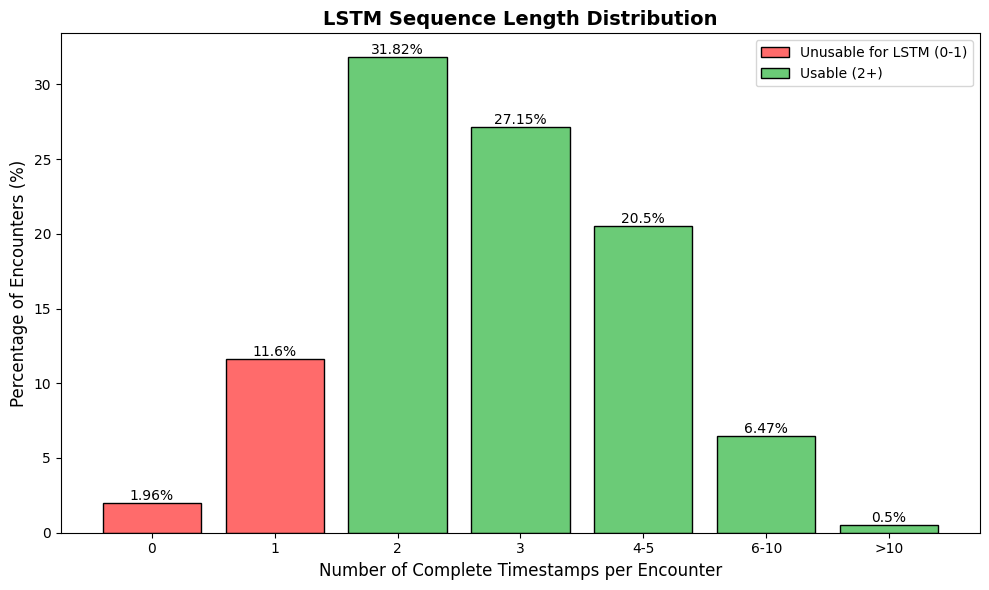


>>> WARNING: 13.559999999999999% of encounters have 0-1 complete timestamps (unusable for sequence modeling)


In [24]:
# Sequence length histogram
print("\n--- Sequence Length Distribution ---")
seq_hist = conn.execute("""
    WITH timestamp_vitals AS (
        SELECT 
            encounter_id,
            effective_datetime,
            COUNT(DISTINCT loinc_code) as num_vitals
        FROM vitals
        GROUP BY encounter_id, effective_datetime
    ),
    enc_counts AS (
        SELECT 
            encounter_id,
            SUM(CASE WHEN num_vitals = 6 THEN 1 ELSE 0 END) as complete_ts
        FROM timestamp_vitals
        GROUP BY encounter_id
    )
    SELECT 
        CASE 
            WHEN complete_ts = 0 THEN '0'
            WHEN complete_ts = 1 THEN '1'
            WHEN complete_ts = 2 THEN '2'
            WHEN complete_ts = 3 THEN '3'
            WHEN complete_ts <= 5 THEN '4-5'
            WHEN complete_ts <= 10 THEN '6-10'
            ELSE '>10'
        END as seq_length,
        CASE 
            WHEN complete_ts = 0 THEN 0
            WHEN complete_ts = 1 THEN 1
            WHEN complete_ts = 2 THEN 2
            WHEN complete_ts = 3 THEN 3
            WHEN complete_ts <= 5 THEN 4
            WHEN complete_ts <= 10 THEN 5
            ELSE 6
        END as bucket_order,
        COUNT(*) as num_encounters,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) as pct
    FROM enc_counts
    GROUP BY 1, 2
    ORDER BY bucket_order
""").df()
seq_hist['cumulative_pct'] = seq_hist['pct'].cumsum().round(2)
display(seq_hist[['seq_length', 'num_encounters', 'pct', 'cumulative_pct']])

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#ff6b6b' if x in ['0', '1'] else '#6bcb77' for x in seq_hist['seq_length']]
bars = ax.bar(seq_hist['seq_length'], seq_hist['pct'], color=colors, edgecolor='black')
ax.set_xlabel('Number of Complete Timestamps per Encounter', fontsize=12)
ax.set_ylabel('Percentage of Encounters (%)', fontsize=12)
ax.set_title('LSTM Sequence Length Distribution', fontsize=14, fontweight='bold')

for bar, pct in zip(bars, seq_hist['pct']):
    ax.annotate(f'{pct}%', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=10)

# Legend
legend_elements = [
    Patch(facecolor='#ff6b6b', edgecolor='black', label='Unusable for LSTM (0-1)'),
    Patch(facecolor='#6bcb77', edgecolor='black', label='Usable (2+)')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

unusable_pct = seq_hist[seq_hist['seq_length'].isin(['0', '1'])]['pct'].sum()
print(f"\n>>> WARNING: {unusable_pct}% of encounters have 0-1 complete timestamps (unusable for sequence modeling)")

## 8. Timestep Coverage Analysis

What percentage of time deltas would be covered by different fixed timestep choices?

TIMESTEP COVERAGE ANALYSIS

--- What % of deltas fall within each timestep? ---


,timestep_min,timestep_label,pct_covered,gaps_to_fill
0,60,1 hour,23.1,76.9
1,120,2 hours,37.9,62.1
2,180,3 hours,55.2,44.8
3,240,4 hours,70.6,29.4
4,360,6 hours,88.3,11.7
5,480,8 hours,95.0,5.0


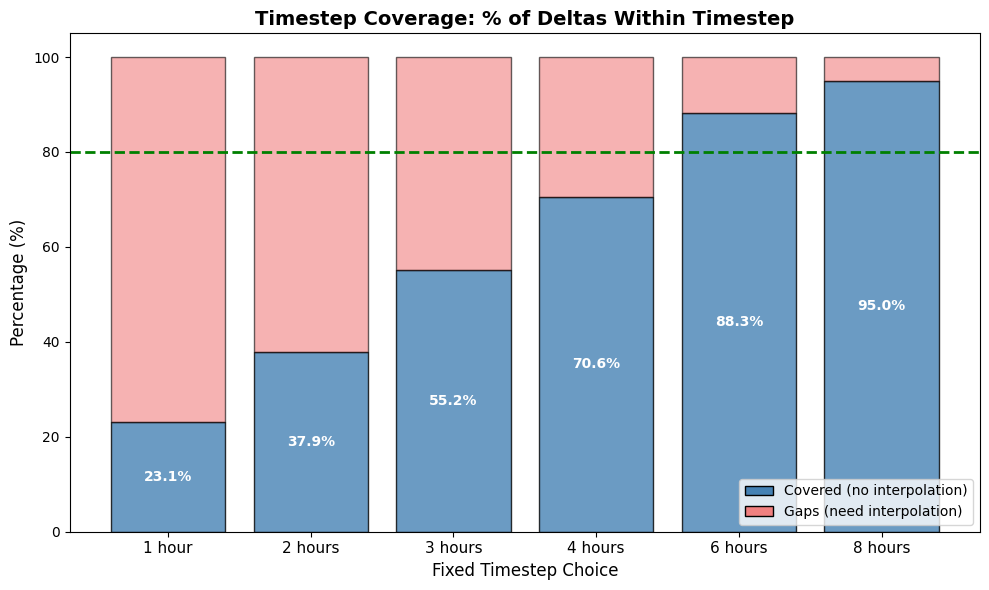

In [25]:
print("=" * 60)
print("TIMESTEP COVERAGE ANALYSIS")
print("=" * 60)

print("\n--- What % of deltas fall within each timestep? ---")
coverage = conn.execute("""
    WITH timestamp_vitals AS (
        SELECT 
            encounter_id,
            effective_datetime::TIMESTAMP as ts,
            COUNT(DISTINCT loinc_code) as num_vitals
        FROM vitals
        GROUP BY encounter_id, effective_datetime
    ),
    complete_ts AS (
        SELECT encounter_id, ts
        FROM timestamp_vitals
        WHERE num_vitals = 6
    ),
    deltas AS (
        SELECT 
            EXTRACT(EPOCH FROM (ts - LAG(ts) OVER (PARTITION BY encounter_id ORDER BY ts))) / 60.0 as delta_min
        FROM complete_ts
    )
    SELECT 
        60 as timestep_min,
        '1 hour' as timestep_label,
        ROUND(100.0 * SUM(CASE WHEN delta_min <= 60 THEN 1 ELSE 0 END) / COUNT(*), 1) as pct_covered
    FROM deltas WHERE delta_min IS NOT NULL
    UNION ALL SELECT 120, '2 hours', ROUND(100.0 * SUM(CASE WHEN delta_min <= 120 THEN 1 ELSE 0 END) / COUNT(*), 1) FROM deltas WHERE delta_min IS NOT NULL
    UNION ALL SELECT 180, '3 hours', ROUND(100.0 * SUM(CASE WHEN delta_min <= 180 THEN 1 ELSE 0 END) / COUNT(*), 1) FROM deltas WHERE delta_min IS NOT NULL
    UNION ALL SELECT 240, '4 hours', ROUND(100.0 * SUM(CASE WHEN delta_min <= 240 THEN 1 ELSE 0 END) / COUNT(*), 1) FROM deltas WHERE delta_min IS NOT NULL
    UNION ALL SELECT 360, '6 hours', ROUND(100.0 * SUM(CASE WHEN delta_min <= 360 THEN 1 ELSE 0 END) / COUNT(*), 1) FROM deltas WHERE delta_min IS NOT NULL
    UNION ALL SELECT 480, '8 hours', ROUND(100.0 * SUM(CASE WHEN delta_min <= 480 THEN 1 ELSE 0 END) / COUNT(*), 1) FROM deltas WHERE delta_min IS NOT NULL
""").df()
coverage['gaps_to_fill'] = (100 - coverage['pct_covered']).round(1)
display(coverage)

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(coverage))
bars = ax.bar(x, coverage['pct_covered'], color='steelblue', edgecolor='black', alpha=0.8)
ax.bar(x, coverage['gaps_to_fill'], bottom=coverage['pct_covered'], color='lightcoral', edgecolor='black', alpha=0.6)

ax.set_xticks(x)
ax.set_xticklabels(coverage['timestep_label'], fontsize=11)
ax.set_xlabel('Fixed Timestep Choice', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Timestep Coverage: % of Deltas Within Timestep', fontsize=14, fontweight='bold')
ax.axhline(y=80, color='green', linestyle='--', linewidth=2, label='80% target')

for i, (covered, gap) in enumerate(zip(coverage['pct_covered'], coverage['gaps_to_fill'])):
    ax.annotate(f'{covered}%', xy=(i, covered/2), ha='center', va='center', fontsize=10, fontweight='bold', color='white')

legend_elements = [
    Patch(facecolor='steelblue', edgecolor='black', label='Covered (no interpolation)'),
    Patch(facecolor='lightcoral', edgecolor='black', label='Gaps (need interpolation)')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

## 9. Summary & Recommendations

In [26]:
print("=" * 70)
print("                    SUMMARY & RECOMMENDATIONS")
print("=" * 70)

print("""
KEY FINDINGS
============

1. DATA STRUCTURE:
   - Each row = one vital observation
   - 6 vitals tracked: temperature, HR, RR, SpO2, systolic BP, diastolic BP
   - Multiple vitals recorded at same timestamp stored as separate rows

2. TIMESTAMP COMPLETENESS:
   - 66% of timestamps have all 6 vitals (complete)
   - 27% have 5 vitals (near-complete) 
   - Body temperature is missing 90% of the time when only 5 vitals recorded

3. TIME DELTA (between complete timestamps):
   - Median: ~162 minutes (2.7 hours)
   - p25: 70 minutes, p75: 261 minutes
   - High variability in recording intervals

4. SEQUENCE LENGTH:
   - Median: 3 complete timestamps per encounter
   - Many encounters have very short sequences
   - Some encounters have 0-1 complete timestamps (unusable)

RECOMMENDATIONS FOR LSTM DATA PREPARATION
==========================================

OPTION 1: Variable-length sequences (RECOMMENDED)
   - Use natural timestamps without resampling
   - Include time-since-last-measurement as a feature
   - Pad/mask for batching
   - Best preserves actual clinical timing

OPTION 2: Fixed timestep with 3-4 hour intervals
   - 180-240 min timestep covers 55-71% of natural intervals
   - Use forward-fill or interpolation for gaps
   - Balances coverage vs granularity

OPTION 3: Include near-complete (5+) timestamps
   - Impute missing temperature (most common missing vital)
   - Increases data availability
   - Reduces median delta to ~106 minutes

DATA FILTERING:
   - Filter encounters with < 2 complete timestamps (unusable for sequences)
   - Consider minimum sequence length of 3 for meaningful patterns
""")

# Final summary table
print("\n" + "=" * 70)
print("QUICK REFERENCE TABLE")
print("=" * 70)
summary_table = pd.DataFrame({
    'Metric': [
        'Complete timestamps (6 vitals)',
        'Near-complete timestamps (5+ vitals)',
        'Median time delta (complete)',
        'Median time delta (5+ vitals)',
        'Median sequence length (complete)',
        'Most commonly missing vital'
    ],
    'Value': [
        '66% of timestamps',
        '93% of timestamps',
        '162 min (2.7 hrs)',
        '106 min (1.8 hrs)',
        '3 timestamps/encounter',
        'Body temperature (90%)'
    ]
})
display(summary_table)

                    SUMMARY & RECOMMENDATIONS

KEY FINDINGS

1. DATA STRUCTURE:
   - Each row = one vital observation
   - 6 vitals tracked: temperature, HR, RR, SpO2, systolic BP, diastolic BP
   - Multiple vitals recorded at same timestamp stored as separate rows

2. TIMESTAMP COMPLETENESS:
   - 66% of timestamps have all 6 vitals (complete)
   - 27% have 5 vitals (near-complete) 
   - Body temperature is missing 90% of the time when only 5 vitals recorded

3. TIME DELTA (between complete timestamps):
   - Median: ~162 minutes (2.7 hours)
   - p25: 70 minutes, p75: 261 minutes
   - High variability in recording intervals

4. SEQUENCE LENGTH:
   - Median: 3 complete timestamps per encounter
   - Many encounters have very short sequences
   - Some encounters have 0-1 complete timestamps (unusable)

RECOMMENDATIONS FOR LSTM DATA PREPARATION

OPTION 1: Variable-length sequences (RECOMMENDED)
   - Use natural timestamps without resampling
   - Include time-since-last-measurement as a feat

,Metric,Value
0,Complete timestamps (6 vitals),66% of timestamps
1,Near-complete timestamps (5+ vitals),93% of timestamps
2,Median time delta (complete),162 min (2.7 hrs)
3,Median time delta (5+ vitals),106 min (1.8 hrs)
4,Median sequence length (complete),3 timestamps/encounter
5,Most commonly missing vital,Body temperature (90%)


In [27]:
# Cleanup
conn.close()
print("\nAnalysis complete. Connection closed.")


Analysis complete. Connection closed.
